In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
costs=pd.read_csv(r'E:\Data Mining\PSet4\data\raw\costs_us.csv')
orders=pd.read_csv(r'E:\Data Mining\PSet4\data\raw\orders_log_us.csv')
visits=pd.read_csv(r'E:\Data Mining\PSet4\data\raw\visits_log_us.csv')

In [3]:
def initialExploration(df):
    print(30*'='+'First 10 rows'+'='*30)
    print(df.head(10))
    print(30*'='+'Last 10 rows'+'='*30)
    print(df.tail(10))
    print(30*'='+'Info'+'='*30)
    print(df.info())
    print(30*'='+'Nulls'+'='*30)
    print(df.isnull().sum())
    print(30*'='+'Duplicates'+'='*30)
    print(df.duplicated().sum())

In [4]:
initialExploration(costs)

==============================First 10 rows==============================
   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
5          1  2017-06-06  40.39
6          1  2017-06-07  40.59
7          1  2017-06-08  56.63
8          1  2017-06-09  40.16
9          1  2017-06-10  43.24
==============================Last 10 rows==============================
      source_id          dt  costs
2532         10  2018-05-22  21.70
2533         10  2018-05-23   7.42
2534         10  2018-05-24  10.79
2535         10  2018-05-25  22.21
2536         10  2018-05-26   7.89
2537         10  2018-05-27   9.92
2538         10  2018-05-28  21.26
2539         10  2018-05-29  11.32
2540         10  2018-05-30  33.15
2541         10  2018-05-31  17.60
==============================Info==============================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2

In [5]:
initialExploration(orders)

==============================First 10 rows==============================
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
5  2017-06-01 08:43:00     0.18  10402394430196413321
6  2017-06-01 08:54:00     1.83  12464626743129688638
7  2017-06-01 09:22:00     1.22   3644482766749211722
8  2017-06-01 09:22:00     3.30  17542070709969841479
9  2017-06-01 09:23:00     0.37   1074355127080856382
==============================Last 10 rows==============================
                    Buy Ts  Revenue                   Uid
50405  2018-05-31 23:36:00     0.61   1551265230644458155
50406  2018-05-31 23:40:00     1.16  13121453305610619664
50407  2018-05-31 23:40:00     2.26  15576344609395725707
50408  2018-05-31 23:42:00 

In [6]:
initialExploration(visits)

==============================First 10 rows==============================
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   
5  desktop  2017-09-03 21:36:00          5  2017-09-03 21:35:00   
6  desktop  2018-01-30 12:09:00          1  2018-01-30 11:13:00   
7    touch  2017-11-05 15:15:00          3  2017-11-05 15:14:00   
8  desktop  2017-07-19 10:44:00          3  2017-07-19 10:41:00   
9  desktop  2017-11-08 13:43:00          5  2017-11-08 13:42:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
5  16007536194108375387  
6   66

#### b) Ajusta los tipos de datos: fechas como datetime, identificadores como string/int, etc.

In [7]:
def changeToDateTime(df,column):
    df[column]=pd.to_datetime(df[column])

In [8]:
def standarize_columns(cols):
    cols = cols.str.lower()
    cols = cols.str.replace(' ', '_')
    cols = cols.str.replace('(', '')
    cols = cols.str.replace(')', '')
    return cols

In [9]:
costs.columns=standarize_columns(costs.columns)
orders.columns=standarize_columns(orders.columns)
visits.columns=standarize_columns(visits.columns)

In [10]:
changeToDateTime(costs,'dt')

In [11]:
costsPerDay=costs.groupby(costs['dt']).sum().reset_index()
costsPerDay
 

,dt,source_id,costs
0,2017-06-01,34,735.26
1,2017-06-02,34,721.19
2,2017-06-03,34,450.85
3,2017-06-04,34,761.16
4,2017-06-05,34,821.44
...,...,...,...
359,2018-05-27,34,532.87
360,2018-05-28,34,619.44
361,2018-05-29,34,784.79
362,2018-05-30,34,1183.00


In [12]:
orders

,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450
...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624
50411,2018-05-31 23:50:00,5.80,11369640365507475976
50412,2018-05-31 23:54:00,0.30,1786462140797698849
50413,2018-05-31 23:56:00,3.67,3993697860786194247


In [13]:
changeToDateTime(orders,'buy_ts')

In [14]:
changeToDateTime(visits,'end_ts')
changeToDateTime(visits,'start_ts')

In [15]:
visits.head(5)

,device,end_ts,source_id,start_ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [16]:
print('Min_start_ts:',visits['start_ts'].min())
print('Max_start_ts:',visits['start_ts'].max())
print('Min_end_ts:',visits['end_ts'].min())
print('Max_end_ts',visits['end_ts'].max())


Min_start_ts: 2017-06-01 00:01:00
Max_start_ts: 2018-05-31 23:59:00
Min_end_ts: 2017-06-01 00:02:00
Max_end_ts 2018-06-01 01:26:00


In [17]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


### A.1) ¿Cuántas personas visitan la pagina usan cada día, semana y mes? (DAU, WAU, MAU ).

Agregamos fechas en base a dia, semana, y mes de 'start_ts' para posteriormente luego realizar el conteo de visitas por dia, semana o mes unicos por usuario

In [18]:
visits['start_ts_date'] = visits['start_ts'].dt.date
visits['start_ts_week']=visits['start_ts'].dt.isocalendar().week
visits['start_ts_month']=visits['start_ts'].dt.strftime('%Y-%m-01')

In [19]:
visits

,device,end_ts,source_id,start_ts,uid,start_ts_date,start_ts_week,start_ts_month
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,51,2017-12-01
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,8,2018-02-01
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,20,2018-05-01
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,52,2017-12-01
...,...,...,...,...,...,...,...,...
359395,desktop,2017-07-29 19:07:19,2,2017-07-29 19:07:00,18363291481961487539,2017-07-29,30,2017-07-01
359396,touch,2018-01-25 17:38:19,1,2018-01-25 17:38:00,18370831553019119586,2018-01-25,4,2018-01-01
359397,desktop,2018-03-03 10:12:19,4,2018-03-03 10:12:00,18387297585500748294,2018-03-03,9,2018-03-01
359398,desktop,2017-11-02 10:12:19,5,2017-11-02 10:12:00,18388616944624776485,2017-11-02,44,2017-11-01


### DAU

In [20]:
visitsPerDay=visits.groupby('start_ts_date').agg({'uid':['count','nunique']})
visitsPerDay.columns=['n_visitas','n_personas']
visitsPerDay=visitsPerDay.reset_index()
visitsPerDay

,start_ts_date,n_visitas,n_personas
0,2017-06-01,664,605
1,2017-06-02,658,608
2,2017-06-03,477,445
3,2017-06-04,510,476
4,2017-06-05,893,820
...,...,...,...
359,2018-05-27,672,620
360,2018-05-28,1156,1039
361,2018-05-29,1035,948
362,2018-05-30,1410,1289


Al realizar un groupby por cada dia en este caso podemos encontrar el numero de sesiones y usuarios por cada dia del dataset. 

### WAU

In [21]:
visitsPerWeek=visits.groupby('start_ts_week').agg({'uid':['count','nunique']})
visitsPerWeek.columns=['n_visitas','n_usuarios']
visitsPerWeek=visitsPerWeek.reset_index()
visitsPerWeek

,start_ts_week,n_visitas,n_usuarios
0,1,8057,6918
1,2,7871,6703
2,3,8317,6972
3,4,8488,7060
4,5,9796,8111
5,6,9407,7908
6,7,9272,7759
7,8,8930,7518
8,9,8771,7395
9,10,8147,6844


Si nos enfocamos en el 'n_usuarios' podemos sacar el numero de usuarios uniicos que visitaron en esta semana. La columna de 'n_visitas' son las visitas totales en esa semana

### MAU

In [22]:
visitsPerMonth=visits.groupby('start_ts_month').agg({'uid':['count','nunique']})
visitsPerMonth.columns=['n_visitas','n_usarios']
visitsPerMonth=visitsPerMonth.reset_index()
visitsPerMonth


,start_ts_month,n_visitas,n_usarios
0,2017-06-01,16505,13259
1,2017-07-01,17828,14183
2,2017-08-01,14355,11631
3,2017-09-01,23907,18975
4,2017-10-01,37903,29692
5,2017-11-01,43969,32797
6,2017-12-01,41983,31557
7,2018-01-01,36939,28716
8,2018-02-01,37182,28749
9,2018-03-01,35679,27473


Si nos enfocamos en el 'n_usuarios' podemos sacar el numero de usuarios unicos que visitaron en este mes. La columna de 'n_visitas' son las visitas totales en ese mes.

#### A.2) ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).

In [23]:
visitsPerDay

,start_ts_date,n_visitas,n_personas
0,2017-06-01,664,605
1,2017-06-02,658,608
2,2017-06-03,477,445
3,2017-06-04,510,476
4,2017-06-05,893,820
...,...,...,...
359,2018-05-27,672,620
360,2018-05-28,1156,1039
361,2018-05-29,1035,948
362,2018-05-30,1410,1289


#### A.3) ¿Cuál es la duración de cada sesión? (End_Ts - Start_Ts).

In [24]:
diferencia=visits['end_ts']-visits['start_ts']
duracionSesion=pd.DataFrame(columns=['session_time'])
duracionSesion['session_time']=diferencia
duracionSesion['horas']=duracionSesion['session_time'].dt.seconds/3600
duracionSesion

,session_time,horas
0,0 days 00:18:00,0.300000
1,0 days 00:28:00,0.466667
2,0 days 00:00:00,0.000000
3,0 days 00:24:00,0.400000
4,0 days 00:00:00,0.000000
...,...,...
359395,0 days 00:00:19,0.005278
359396,0 days 00:00:19,0.005278
359397,0 days 00:00:19,0.005278
359398,0 days 00:00:19,0.005278


#### A.4) ¿Con qué frecuencia los usuarios regresan?

In [25]:
visitStartDatesDifference = visits.sort_values(by=['uid','start_ts_date'])
visitStartDatesDifference['date_difference'] = visitStartDatesDifference.groupby('uid')['start_ts_date'].diff()

In [26]:
visitStartDatesDifference['date_difference'] = pd.to_timedelta(visitStartDatesDifference['date_difference'])

In [27]:
visitStartDatesDifference.describe()

,end_ts,source_id,start_ts,uid,start_ts_week,date_difference
count,359400,359400.000000,359400,3.594000e+05,359400.0,131231
mean,2017-12-18 06:28:15.036204544,3.750515,2017-12-18 06:17:32.010517760,9.202557e+18,26.970907,28 days 02:33:52.477082396
min,2017-06-01 00:02:00,1.000000,2017-06-01 00:01:00,1.186350e+13,1.0,0 days 00:00:00
25%,2017-10-15 09:45:45,3.000000,2017-10-15 09:41:00,4.613407e+18,11.0,1 days 00:00:00
50%,2017-12-18 18:59:30,4.000000,2017-12-18 18:46:00,9.227413e+18,26.0,5 days 00:00:00
75%,2018-02-28 10:08:15,5.000000,2018-02-28 09:54:00,1.372824e+19,43.0,32 days 00:00:00
max,2018-06-01 01:26:00,10.000000,2018-05-31 23:59:00,1.844668e+19,52.0,363 days 00:00:00
std,NaN,1.917116,NaN,5.298433e+18,16.77392,49 days 17:31:33.195080023


In [28]:
frequency = visitStartDatesDifference['date_difference'].dt.days.mean()
print(frequency)

28.10685737363885


En promedio los usuarios regresan despues de 28 dias.

In [29]:
frequencyCount=visitStartDatesDifference.value_counts(visitStartDatesDifference['date_difference'])
usersNoReturn=frequencyCount.iloc[0]

In [30]:
totalUsers=visitStartDatesDifference['uid'].nunique()
pusersNoReturn=usersNoReturn*100/totalUsers
print("El",pusersNoReturn,'% de personas nunca regresaron')

El 12.662105719883069 % de personas nunca regresaron


## B. Ventas

### B.1 Cuando empieza la gente a comprar?


In [31]:
first_visit=visits.groupby('uid')['start_ts_date'].min()
first_visit=first_visit.to_frame()
first_visit=first_visit.reset_index()

In [32]:
first_visit

,uid,start_ts_date
0,11863502262781,2018-03-01
1,49537067089222,2018-02-06
2,297729379853735,2017-06-07
3,313578113262317,2017-09-18
4,325320750514679,2017-09-30
...,...,...
228164,18446403737806311543,2017-11-30
228165,18446424184725333426,2017-12-06
228166,18446556406699109058,2018-01-01
228167,18446621818809592527,2017-12-27


Ahora encontramos la primera compra que hizo cada usuario

In [33]:
first_order=orders.groupby('uid')['buy_ts'].min()
first_order=first_order.to_frame()
first_order=first_order.reset_index()
first_order['buy_ts_date']=pd.to_datetime(first_order['buy_ts']).dt.date
first_order=first_order.drop(columns='buy_ts')
first_order_time=pd.DataFrame()
merged_order=pd.merge(first_visit,first_order,on='uid', how='inner')

In [34]:
merged_order

,uid,start_ts_date,buy_ts_date
0,313578113262317,2017-09-18,2018-01-03
1,1575281904278712,2017-06-03,2017-06-03
2,2429014661409475,2017-10-11,2017-10-11
3,2464366381792757,2018-01-27,2018-01-28
4,2551852515556206,2017-11-24,2017-11-24
...,...,...,...
36518,18445147675727495770,2017-08-20,2017-11-24
36519,18445407535914413204,2017-09-22,2017-09-22
36520,18445601152732270159,2017-08-07,2018-03-26
36521,18446156210226471712,2017-11-07,2018-02-18


In [35]:
merged_order['start_ts_date'] = pd.to_datetime(merged_order['start_ts_date'])
merged_order['buy_ts_date'] = pd.to_datetime(merged_order['buy_ts_date'])
merged_order['cohort_month'] = merged_order['start_ts_date'].dt.to_period('M')

merged_order['conversion_month'] = ((merged_order['buy_ts_date'].dt.to_period('M') - merged_order['start_ts_date'].dt.to_period('M')).apply(lambda x: x.n)
)
cohort_data = merged_order.groupby(['cohort_month', 'conversion_month']).agg({'uid': 'nunique'}).reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='conversion_month', values='uid').fillna(0)

cohort_pivot


conversion_month,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2017-06,2023.0,170.0,67.0,107.0,119.0,92.0,78.0,59.0,64.0,64.0,26.0,54.0
2017-07,1753.0,95.0,99.0,100.0,89.0,77.0,67.0,62.0,50.0,33.0,33.0,0.0
2017-08,1208.0,118.0,92.0,73.0,65.0,38.0,39.0,38.0,25.0,25.0,0.0,0.0
2017-09,2257.0,268.0,143.0,102.0,59.0,76.0,71.0,40.0,42.0,0.0,0.0,0.0
2017-10,3761.0,327.0,178.0,114.0,97.0,92.0,49.0,60.0,0.0,0.0,0.0,0.0
2017-11,3357.0,392.0,155.0,102.0,127.0,64.0,65.0,0.0,0.0,0.0,0.0,0.0
2017-12,3491.0,237.0,115.0,112.0,45.0,74.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01,2644.0,244.0,114.0,50.0,67.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-02,2852.0,202.0,62.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### B.2) ¿Cuántos pedidos hacen durante un período de tiempo dado?

In [36]:
merged_order['buy_ts_date'] = pd.to_datetime(merged_order['buy_ts_date'])
merged_order['buy_month'] = merged_order['buy_ts_date'].dt.to_period('M')
orders_per_month = merged_order.groupby('buy_month').size().reset_index(name='num_orders')
orders_per_month

,buy_month,num_orders
0,2017-06,2023
1,2017-07,1923
2,2017-08,1370
3,2017-09,2581
4,2017-10,4340
5,2017-11,4081
6,2017-12,4383
7,2018-01,3373
8,2018-02,3651
9,2018-03,3533


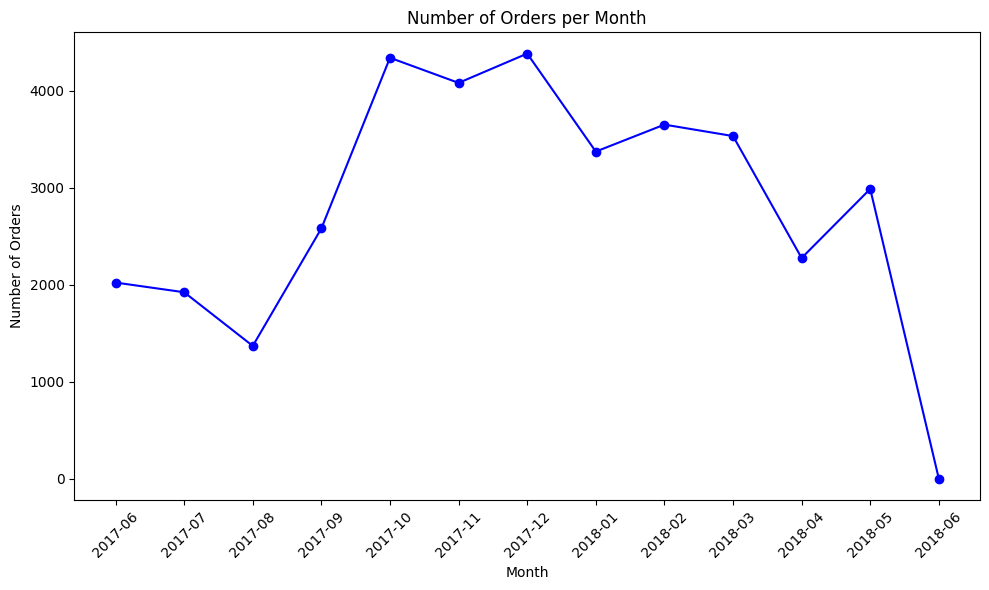

In [37]:
orders_per_month['buy_month'] = orders_per_month['buy_month'].astype(str)

plt.figure(figsize=(10, 6))
plt.plot(orders_per_month['buy_month'], orders_per_month['num_orders'], marker='o', color='b')

plt.title('Number of Orders per Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


#### B.3) ¿Cuál es el tamaño promedio de compra? Ticket promedio.

Ticket Promedio = Total de ingresos (o costos) / Número de compras

In [38]:
total_revenue=orders['revenue'].sum()
number_orders=len(orders)
average_ticket=total_revenue/number_orders
average_ticket = round(average_ticket, 4)
print("Ticket Promedio:",average_ticket)

Ticket Promedio: 4.9996


#### B.4) ¿Cuánto dinero traen? Lifetime Value (LTV) por cohorte

In [39]:
orders['cohort_month'] = orders.groupby('uid')['buy_ts'].transform('min').dt.to_period('M')
cohort_revenue = orders.groupby(['cohort_month', 'uid']).agg({'revenue': 'sum'}).reset_index()
ltv_table = cohort_revenue.groupby('cohort_month').agg(total_revenue=('revenue', 'sum'),num_users=('uid', 'nunique')).reset_index()
ltv_table['LTV'] = ltv_table['total_revenue'] / ltv_table['num_users']
ltv_table


,cohort_month,total_revenue,num_users,LTV
0,2017-06,24031.69,2023,11.879234
1,2017-07,16127.92,1923,8.386854
2,2017-08,11606.26,1370,8.471723
3,2017-09,34676.32,2581,13.435227
4,2017-10,27603.45,4340,6.360242
5,2017-11,26098.99,4081,6.395244
6,2017-12,33485.74,4383,7.639913
7,2018-01,16663.13,3373,4.940151
8,2018-02,16750.50,3651,4.587921
9,2018-03,19273.41,3533,5.455253


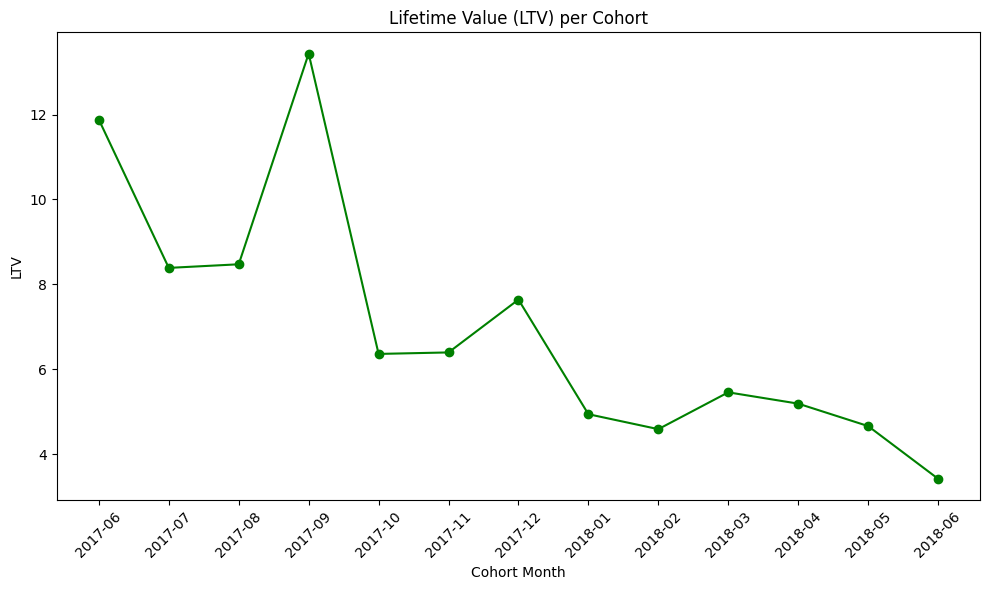

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(ltv_table['cohort_month'].astype(str), ltv_table['LTV'], marker='o', color='g')

plt.title('Lifetime Value (LTV) per Cohort')
plt.xlabel('Cohort Month')
plt.ylabel('LTV')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## MARKETING

C.1) Gastos totales y por fuente a lo largo del tiempo.

In [41]:
costsPerDay

,dt,source_id,costs
0,2017-06-01,34,735.26
1,2017-06-02,34,721.19
2,2017-06-03,34,450.85
3,2017-06-04,34,761.16
4,2017-06-05,34,821.44
...,...,...,...
359,2018-05-27,34,532.87
360,2018-05-28,34,619.44
361,2018-05-29,34,784.79
362,2018-05-30,34,1183.00


In [42]:
costsPerDay['costs'].describe()

count     364.000000
mean      904.207747
std       396.956825
min         0.700000
25%       595.682500
50%       873.655000
75%      1155.605000
max      3458.860000
Name: costs, dtype: float64

C:\Users\Elias\AppData\Local\Temp\ipykernel_11176\1984794940.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


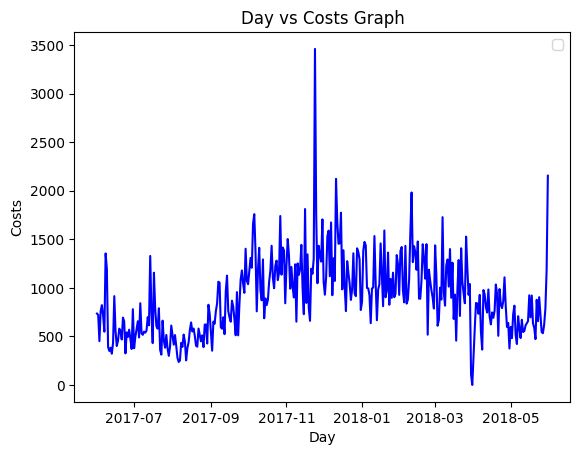

In [43]:
plt.plot(costsPerDay['dt'], costsPerDay['costs'], linestyle='-', color='blue', )

plt.xlabel('Day')
plt.ylabel('Costs')
plt.title('Day vs Costs Graph')
plt.legend()

plt.show()

In [44]:
costs['dt_month']=pd.to_datetime(costs['dt'].dt.strftime('%Y-%m-01'))

In [45]:
costs

,source_id,dt,costs,dt_month
0,1,2017-06-01,75.20,2017-06-01
1,1,2017-06-02,62.25,2017-06-01
2,1,2017-06-03,36.53,2017-06-01
3,1,2017-06-04,55.00,2017-06-01
4,1,2017-06-05,57.08,2017-06-01
...,...,...,...,...
2537,10,2018-05-27,9.92,2018-05-01
2538,10,2018-05-28,21.26,2018-05-01
2539,10,2018-05-29,11.32,2018-05-01
2540,10,2018-05-30,33.15,2018-05-01


In [46]:
costsPerMonth=costs.groupby(['source_id','dt_month'])['costs'].sum().reset_index()
costsPerMonth

,source_id,dt_month,costs
0,1,2017-06-01,1125.61
1,1,2017-07-01,1072.88
2,1,2017-08-01,951.81
3,1,2017-09-01,1502.01
4,1,2017-10-01,2315.75
...,...,...,...
79,10,2018-01-01,614.35
80,10,2018-02-01,480.88
81,10,2018-03-01,526.41
82,10,2018-04-01,388.25


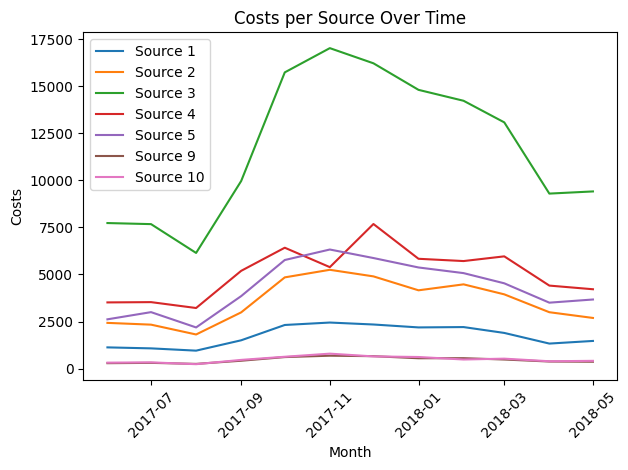

In [47]:

for source_id, group in costsPerMonth.groupby('source_id'):
    plt.plot(group['dt_month'], group['costs'], label=f'Source {source_id}')

plt.xlabel('Month')
plt.ylabel('Costs')
plt.title('Costs per Source Over Time')
plt.legend()
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()


In [48]:
costsPerMonth['costs'].describe()

count       84.000000
mean      3918.233571
std       3991.439304
min        232.570000
25%        654.950000
50%       2837.550000
75%       5375.845000
max      17025.340000
Name: costs, dtype: float64

Gastos totales por fuente:

In [49]:
total_costs_source=costsPerMonth.groupby('source_id')['costs'].sum().reset_index()
total_costs_source

,source_id,costs
0,1,20833.27
1,2,42806.04
2,3,141321.63
3,4,61073.60
4,5,51757.10
5,9,5517.49
6,10,5822.49


### C.2) ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes? Customer Acquisition Cost (CAC) por fuente.

In [50]:
users_per_source=visits.groupby('source_id')['uid'].unique().reset_index()
users_per_source['user_number']=users_per_source['uid'].apply(len)
users_per_source=users_per_source.drop(columns='uid')
users_per_source

,source_id,user_number
0,1,18999
1,2,26245
2,3,74756
3,4,83525
4,5,56974
5,6,6
6,7,34
7,9,9264
8,10,8067


In [51]:
users_per_source = users_per_source[~users_per_source['source_id'].isin([6, 7])]
users_per_source=users_per_source.reset_index()
users_per_source


,index,source_id,user_number
0,0,1,18999
1,1,2,26245
2,2,3,74756
3,3,4,83525
4,4,5,56974
5,7,9,9264
6,8,10,8067


In [52]:
users_per_source['cac']=total_costs_source['costs']/users_per_source['user_number']
users_per_source

,index,source_id,user_number,cac
0,0,1,18999,1.096546
1,1,2,26245,1.631017
2,2,3,74756,1.890439
3,3,4,83525,0.731201
4,4,5,56974,0.908434
5,7,9,9264,0.595584
6,8,10,8067,0.721766


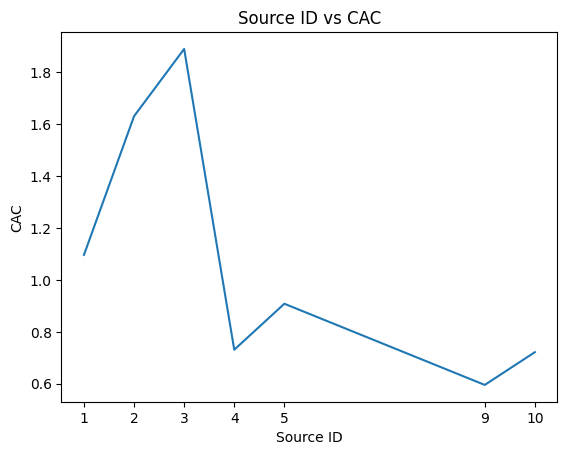

In [53]:

plt.plot(users_per_source['source_id'], users_per_source['cac'])
plt.xlabel('Source ID')
plt.ylabel('CAC')
plt.title('Source ID vs CAC')
plt.xticks(users_per_source['source_id'])
plt.show()

### C.3) ¿Cuán rentables eran las inversiones? Return on Marketing Investment (ROMI) temporal y por fuente

In [54]:
revenue_per_customer=orders.groupby('uid')['revenue'].sum().reset_index()
revenue_per_customer

,uid,revenue
0,313578113262317,0.55
1,1575281904278712,3.05
2,2429014661409475,73.33
3,2464366381792757,2.44
4,2551852515556206,10.99
...,...,...
36518,18445147675727495770,3.05
36519,18445407535914413204,0.88
36520,18445601152732270159,4.22
36521,18446156210226471712,9.78


In [55]:
orders_and_source=visits.drop_duplicates(subset='uid')
orders_and_source=orders_and_source.merge(revenue_per_customer,on='uid',how='inner')
orders_and_source=orders_and_source[['uid','source_id']]
orders_and_source

,uid,source_id
0,16174680259334210214,9
1,16007536194108375387,5
2,8056418121947262981,4
3,18188358787673499603,2
4,2307401184189569202,4
...,...,...
36518,6752020629696526518,3
36519,11750532881998794555,4
36520,11202626539189016002,4
36521,12734910664455613822,10


In [56]:
revenue_source=orders_and_source.merge(revenue_per_customer,on='uid',how='left')

In [57]:
revenue_source

,uid,source_id,revenue
0,16174680259334210214,9,2.33
1,16007536194108375387,5,5.50
2,8056418121947262981,4,466.57
3,18188358787673499603,2,0.79
4,2307401184189569202,4,3.67
...,...,...,...
36518,6752020629696526518,3,4.15
36519,11750532881998794555,4,3.67
36520,11202626539189016002,4,3.05
36521,12734910664455613822,10,0.49


In [58]:

revenue_source=revenue_source.groupby('source_id')['revenue'].sum().reset_index()
revenue_source=revenue_source[revenue_source['source_id']!=7].reset_index()
revenue_source

,index,source_id,revenue
0,0,1,38560.06
1,1,2,65152.26
2,2,3,44317.68
3,3,4,52479.75
4,4,5,40357.91
5,6,9,7076.98
6,7,10,4111.34


In [59]:
total_costs_source

,source_id,costs
0,1,20833.27
1,2,42806.04
2,3,141321.63
3,4,61073.60
4,5,51757.10
5,9,5517.49
6,10,5822.49


ROMI= (Ingresos-Costos)/Costos

In [60]:
ROMI=pd.DataFrame(columns=['source_id'])
ROMI['source_id']=total_costs_source['source_id']
ROMI['value']=(revenue_source['revenue']-total_costs_source['costs'])/total_costs_source['costs']
ROMI

,source_id,value
0,1,0.850889
1,2,0.522034
2,3,-0.686406
3,4,-0.140713
4,5,-0.220244
5,9,0.282645
6,10,-0.293886


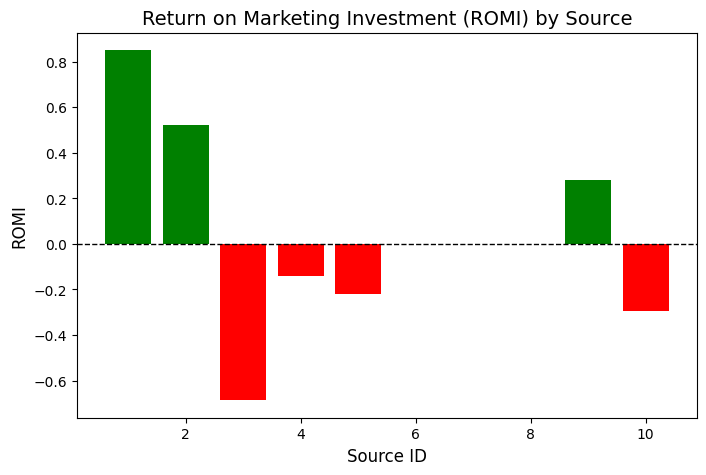

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

colors = ['green' if val > 0 else 'red' for val in ROMI['value']]

plt.bar(ROMI['source_id'], ROMI['value'], color=colors)

plt.title('Return on Marketing Investment (ROMI) by Source', fontsize=14)
plt.xlabel('Source ID', fontsize=12)
plt.ylabel('ROMI', fontsize=12)

plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.show()


In [62]:
##unique_visits=visits.groupby('source_id')['uid'].unique().reset_index()
##unique_visits['number_of_users']=unique_visits['uid'].apply(len)
##unique_visits = unique_visits[unique_visits['source_id'] != 6]
##unique_visits = unique_visits[unique_visits['source_id'] != 7]
##unique_visits=unique_visits.drop(columns='uid')

In [63]:
costs.to_csv(r'E:\Data Mining\PSet4\data\clean\costs_us.csv', index=False)
orders.to_csv(r'E:\Data Mining\PSet4\data\clean\orders_log_us.csv', index=False)
visits.to_csv(r'E:\Data Mining\PSet4\data\clean\visits_log_us.csv', index=False)


# Conclusiones y recomendaciones

En base a nuestro analisis de datos pudimos observar que la mayoria de los clientes entraron en el mes de 2017-10 y en base al grafico de numero de ordenes por mes observamos que la mayoria de las ordenes se realizan entre los meses de 2017-10 y 2018-03. 

En base al ticket promedio cada uno de los pedidos que has procesado en tu base de datos tiene un valor promedio de 4.9996

Ahora que analizamos la metrica de LTV por cada cohorte , el cual esta dividido en meses, podemos observar que esta en constante declive. Nuestro mejor valor de LTV surge en el cohorte de 2017-09 con 13.43 y tiene declive hasta que finaliza en el ulitmo mes. Hay que tomar en cuenta que el LTV es una metrica acumulativa por lo cual puede disminuir el LTV a medida que pasan los meses ya que nuestro dataset no tiene mas data despues del 2018-06

Los costos tocan un pico al final del año 2017 y luego disminuye gradualmente, esto se puede dar por festividades en Diciembre y Fin de año

Analizando las fuentes , la fuente que mayor costo tuvo fue la #3 y la mas baja la #10. Hay que tomar en cuenta la distribucion de fondo de estas inversiones tomando en cuenta que se debe invertir mas en las que generan mas costos y talvez redirigir los costos a las otras fuentes

De misma manera lo mismo ocurre analizando el CAC. La metrica de CAC se coloca mas alto en la fuente 3 

Las fuentes que mas han generado retorno en base al ROMI han sido la 1 2 y 7 , mientras que en las otras han existido perdidas. 

En resumen:


Costos Diarios: Los costos varían significativamente entre días, con un promedio diario de aproximadamente $1,183 (basado en los datos de costsPerDay).

Visitas y Usuarios Únicos:

DAU: En promedio, hay alrededor de 1,000 usuarios únicos por día, con picos de hasta 1,997 usuarios en días de alta actividad (ej. 2018-05-31).

WAU: Semanalmente, hay entre 6,000 y 10,000 usuarios únicos, dependiendo de la semana.

MAU: Mensualmente, la cantidad de usuarios únicos varía, pero se observa un crecimiento hacia finales del período analizado.

Frecuencia de Retorno: Los usuarios regresan en promedio cada 28 días, y aproximadamente el 12.66% no regresa después de su primera visita.

Ventas: Hay 50,415 órdenes registradas, con ingresos variables por transacción 

#### Distrubicion de Inversion

Basado en el análisis de los datos, se recomienda distribuir el presupuesto de marketing de la siguiente manera:

Canales Principales (70% del presupuesto):

Canal 4 (25%) y Canal 3 (25%) reciben la mayor inversión debido a su alto retorno y equilibrio entre costos y efectividad.

Canal 1 (20%) se prioriza por su alto tráfico, aunque con un retorno ligeramente menor.

Canales Secundarios (15% del presupuesto):

Canal 5 (15%) se asigna un porcentaje moderado por su buen engagement a bajo costo.

Canales de Menor Prioridad (8% del presupuesto):

Canal 2 (7%) y Canal 9 (5%) reciben una inversión reducida por su impacto limitado.

Canal 10 (3%) se asigna el mínimo por su bajo tráfico y retorno.



#### Limitaciones y supuestos

Hay que tomar en cuenta que nuestro periodo de analisis es en un año desde mediados de 2017 hasta mediados de 2018 por lo cual analisis a largo plazo no son totalmente analizadas , aun mas tomando en cuenta nuestro analisis de cohortes que realizamos. 

Por otra parte otra seria fundmaental trabajar con metrica para conocer el retorno de inversion la cual puede ser el ROI, no solo en el aspecto de marketing el cual es el ROMI.

Datos demograficos, caracteristicas de los usuarios ya sea edad, genero, no fueron analizados por lo cual se podria analizar de manera mas profunda si es que se plantea una estrategia de marketing, con el proposito de analizar que clientela utiliza mayormente que fuente y en que mes mayormente interactuan con el sistema